<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/pgmsiamese11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# Define the structure of the Bayesian Network
# S -> L -> C
model = DiscreteBayesianNetwork([('S', 'L'), ('L', 'C')])

# Define Conditional Probability Distributions (CPDs)
# CPD for Smoker (S)
cpd_s = TabularCPD(variable='S', variable_card=2, values=[[0.7], [0.3]]) # P(S=False)=0.7, P(S=True)=0.3

# CPD for Lung Cancer (L) given Smoker (S)
cpd_l = TabularCPD(variable='L', variable_card=2,
                   values=[[0.99, 0.9],   # P(L=False|S=False), P(L=False|S=True)
                           [0.01, 0.1]],  # P(L=True|S=False), P(L=True|S=True)
                   evidence=['S'], evidence_card=[2])

# CPD for Cough (C) given Lung Cancer (L)
cpd_c = TabularCPD(variable='C', variable_card=2,
                   values=[[0.95, 0.4],   # P(C=False|L=False), P(C=False|L=True)
                           [0.05, 0.6]],  # P(C=True|L=False), P(C=True|L=True)
                   evidence=['L'], evidence_card=[2])

# Add CPDs to the model
model.add_cpds(cpd_s, cpd_l, cpd_c)

# Check if the model is consistent
print("Model is consistent:", model.check_model())

Model is consistent: True


In [61]:
from pgmpy.inference import VariableElimination

# Perform inference
infer = VariableElimination(model)

# Query: What is the probability of Lung Cancer (L) given Smoker (S=True) and Cough (C=True)?
# S=0 is False, S=1 is True
# L=0 is False, L=1 is True
# C=0 is False, C=1 is True

print("\nInference Results:")

# P(L | S=True, C=True)
query_result = infer.query(variables=['L'], evidence={'S': 1, 'C': 1})
print(query_result)


Inference Results:
+------+----------+
| L    |   phi(L) |
+======+==========+
| L(0) |   0.4286 |
+------+----------+
| L(1) |   0.5714 |
+------+----------+


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from tensorflow.keras.datasets import mnist

# --- 1. Data Loading and Feature Extraction (Re-run from 3bd4084c) ---

# Load and preprocess data (re-added for self-contained execution)
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_test = x_test.astype("float32") / 255.0 # Normalize
x_test = np.expand_dims(x_test, -1) # Reshape for CNN

def extract_quadrant_features(image):
    h, w = image.shape[0], image.shape[1]
    h_half, w_half = h // 2, w // 2
    top_left = image[0:h_half, 0:w_half]
    top_right = image[0:h_half, w_half:w]
    bottom_left = image[h_half:h, 0:w_half]
    bottom_right = image[h_half:h, w_half:w]
    features = {
        'TL': np.mean(top_left),
        'TR': np.mean(top_right),
        'BL': np.mean(bottom_left),
        'BR': np.mean(bottom_right)
    }
    return features

np.random.seed(42) # for reproducibility
sample_indices = np.random.choice(len(x_test), 1000, replace=False)
x_test_subset = x_test[sample_indices]
y_test_subset = y_test[sample_indices]

raw_features = []
for img in x_test_subset:
    raw_features.append(extract_quadrant_features(img.squeeze()))
raw_features_df = pd.DataFrame(raw_features)

In [63]:
# --- 2. Discretization (Modified for 5 bins) ---

def discretize_feature(value, feature_name, quantiles_df):
    # Using 5 bins: 'very_low', 'low', 'medium', 'high', 'very_high'
    q20 = quantiles_df.loc[0.20, feature_name]
    q40 = quantiles_df.loc[0.40, feature_name]
    q60 = quantiles_df.loc[0.60, feature_name]
    q80 = quantiles_df.loc[0.80, feature_name]

    if value <= q20:
        return 'very_low'
    elif value <= q40:
        return 'low'
    elif value <= q60:
        return 'medium'
    elif value <= q80:
        return 'high'
    else:
        return 'very_high'

# Using quintiles for 5 bins
quantiles_df = raw_features_df.quantile([0.20, 0.40, 0.60, 0.80])

discrete_features = raw_features_df.copy()
for col in raw_features_df.columns:
    discrete_features[col] = raw_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_df))
discrete_features_df = discrete_features

In [64]:
# --- 3. Combine Discretized Features and Labels (Re-run from 0eca586b) ---

labels_df = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_df = pd.concat([discrete_features_df, labels_df], axis=1)

In [65]:
# --- 4. Build Bayesian Network Structure (Re-run from 89a4152b) ---

bn_model = DiscreteBayesianNetwork([
    ('digit_label', 'TL'),
    ('digit_label', 'TR'),
    ('digit_label', 'BL'),
    ('digit_label', 'BR')
])

In [66]:
# --- 5. Define Conditional Probability Distributions (CPDs) (Modified for 5 bins) ---

quadrant_cardinality = 5 # Updated to 5 bins
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Updated categories
digit_label_cardinality = 10

digit_counts = pgm_data_df['digit_label'].value_counts().sort_index()
digit_probabilities = digit_counts.values / len(pgm_data_df)
digit_probabilities_2d = digit_probabilities.reshape(-1, 1)

cpd_digit_label = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_2d
)

cpd_quadrants = []
category_map = {cat: i for i, cat in enumerate(quadrant_categories)}

for quadrant_feature in ['TL', 'TR', 'BL', 'BR']:
    values = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data = pgm_data_df[pgm_data_df['digit_label'] == digit]
        if not digit_data.empty:
            quadrant_counts = digit_data[quadrant_feature].value_counts()
            for category, count in quadrant_counts.items():
                if category in category_map:
                    values[category_map[category], digit] = count / len(digit_data)
            col_sum = np.sum(values[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum > 0:
                values[:, digit] /= col_sum

    cpd = TabularCPD(
        variable=quadrant_feature,
        variable_card=quadrant_cardinality,
        values=values,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            quadrant_feature: quadrant_categories, # Updated state names
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_quadrants.append(cpd)
bn_model.add_cpds(cpd_digit_label, *cpd_quadrants)

# Check if the model is consistent after adding all CPDs
print("\nModel is consistent after adding all CPDs:", bn_model.check_model())


Model is consistent after adding all CPDs: True


In [67]:
# --- 6. Perform Inference (Re-run with new CPDs) ---

infer = VariableElimination(bn_model)

all_test_indices = set(range(len(x_test)))
pgm_train_indices = set(sample_indices)
available_test_indices = list(all_test_indices - pgm_train_indices)

if not available_test_indices:
    test_img_idx = np.random.choice(len(x_test))
else:
    test_img_idx = np.random.choice(available_test_indices)

query_image_pgm = x_test[test_img_idx]
true_label_pgm = y_test[test_img_idx]
raw_features_pgm = extract_quadrant_features(query_image_pgm.squeeze())

discrete_features_pgm = {}
for feature_name, value in raw_features_pgm.items():
    discrete_features_pgm[feature_name] = discretize_feature(value, feature_name, quantiles_df)

query_result = infer.query(variables=['digit_label'], evidence=discrete_features_pgm)
predicted_label_pgm = query_result.values.argmax()

print(f"\nSelected test image index: {test_img_idx}")
print(f"True Label: {true_label_pgm}")
print(f"Raw Quadrant Features: {raw_features_pgm}")
print(f"Discretized Quadrant Features: {discrete_features_pgm}")
print(f"Predicted Label: {predicted_label_pgm}")
print("\nProbability distribution over digit_label:")
print(query_result)


Selected test image index: 1950
True Label: 7
Raw Quadrant Features: {'TL': np.float32(0.101700686), 'TR': np.float32(0.10572229), 'BL': np.float32(0.0232493), 'BR': np.float32(0.12773108)}
Discretized Quadrant Features: {'TL': 'medium', 'TR': 'low', 'BL': 'very_low', 'BR': 'low'}
Predicted Label: 7

Probability distribution over digit_label:
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.0000 |
+----------------+--------------------+
| digit_label(1) |             0.0517 |
+----------------+--------------------+
| digit_label(2) |             0.0123 |
+----------------+--------------------+
| digit_label(3) |             0.0497 |
+----------------+--------------------+
| digit_label(4) |             0.2363 |
+----------------+--------------------+
| digit_label(5) |             0.0410 |
+----------------+--------------------+
| digit_label(6) |             0.0027 |
+-------------

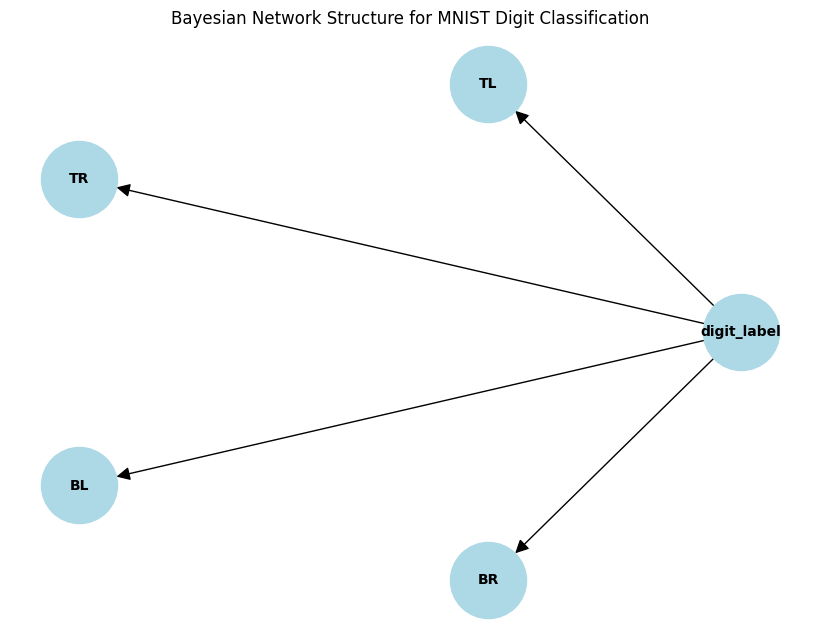

In [68]:
# --- 7. Bayesian Network Structure Visualization ---

plt.figure(figsize=(8, 6))
pos = nx.circular_layout(bn_model)
nx.draw(bn_model, pos=pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Bayesian Network Structure for MNIST Digit Classification")
plt.show()

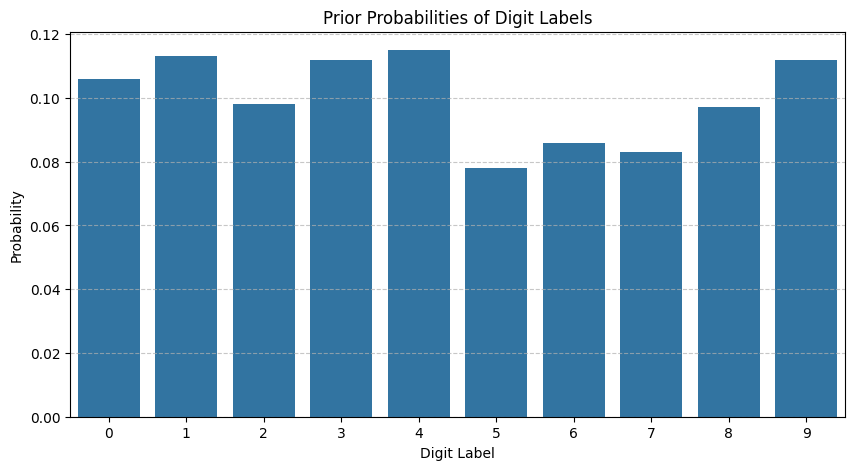

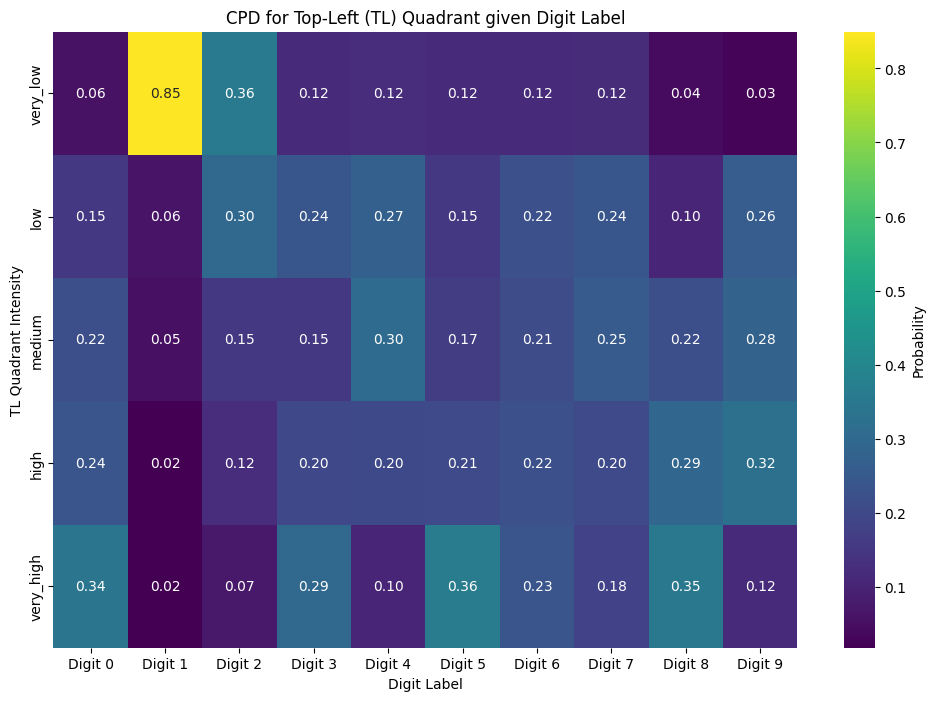

In [69]:
# --- 8. Conditional Probability Distribution (CPD) Visualizations ---

# Visualize CPD for digit_label (prior)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(range(digit_label_cardinality)), y=cpd_digit_label.values.flatten())
plt.title("Prior Probabilities of Digit Labels")
plt.xlabel("Digit Label")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize CPD for TL given digit_label as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cpd_quadrants[0].values, # Assuming cpd_quadrants[0] is for 'TL'
    xticklabels=[f'Digit {i}' for i in range(digit_label_cardinality)],
    yticklabels=quadrant_categories, # Updated categories
    annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Probability'}
)
plt.title("CPD for Top-Left (TL) Quadrant given Digit Label")
plt.xlabel("Digit Label")
plt.ylabel("TL Quadrant Intensity")
plt.show()

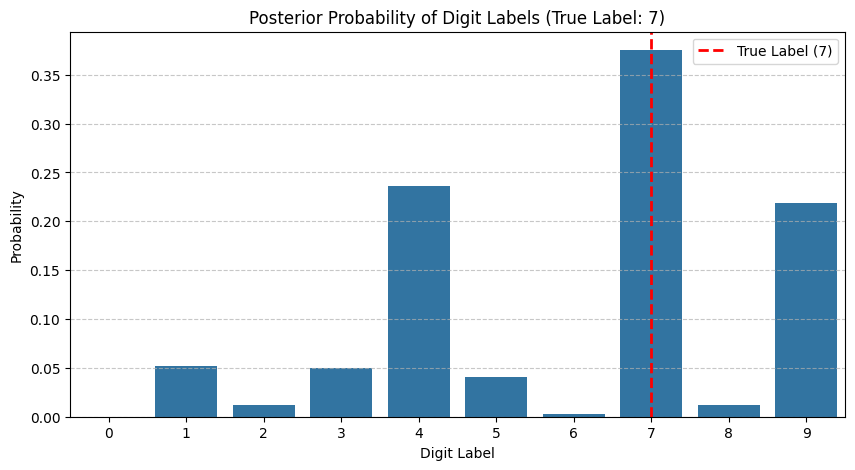

In [70]:
# --- 9. Inference Result Visualization ---

plt.figure(figsize=(10, 5))
sns.barplot(x=list(range(digit_label_cardinality)), y=query_result.values.flatten())
plt.title(f"Posterior Probability of Digit Labels (True Label: {true_label_pgm})")
plt.xlabel("Digit Label")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.axvline(x=true_label_pgm, color='red', linestyle='--', linewidth=2, label=f'True Label ({true_label_pgm})')
plt.legend()
plt.show()

In [71]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test subset
pgm_predictions = []
pgm_true_labels = []

# We will use the x_test_subset and y_test_subset that were already created for PGM training.
# If you wish to use a completely separate test set, you would need to load and preprocess it here.

print("Generating PGM predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract and discretize features for the current image
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    predicted_label = query_result_subset.values.argmax()

    pgm_predictions.append(predicted_label)
    pgm_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix...")

# Calculate the confusion matrix
cm = confusion_matrix(pgm_true_labels, pgm_predictions, labels=range(digit_label_cardinality))

# Print classification report for more detailed metrics (optional)
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(pgm_true_labels, pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("Confusion Matrix:")
print(cm)

Generating PGM predictions for the test subset...
Predictions generated. Calculating confusion matrix...

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000

Confusion Matrix:
[[71  6  8  1  5  3  1  0  2  9]
 [ 0 91  7  1 11  2  0  0  0  1]
 [23 16 33  0 12  0  2  2  3

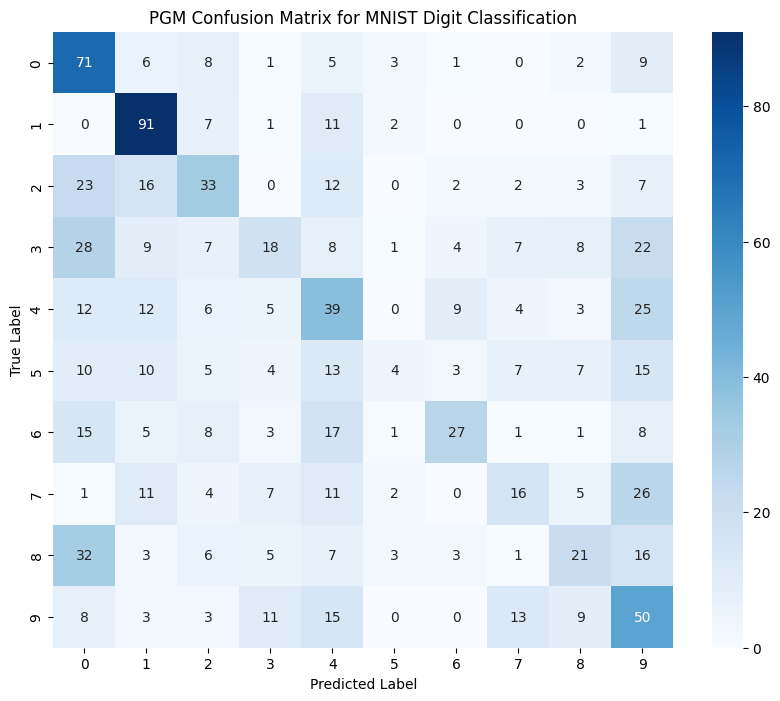

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM Confusion Matrix for MNIST Digit Classification')
plt.show()

Generating PGM prediction probabilities for ROC analysis...


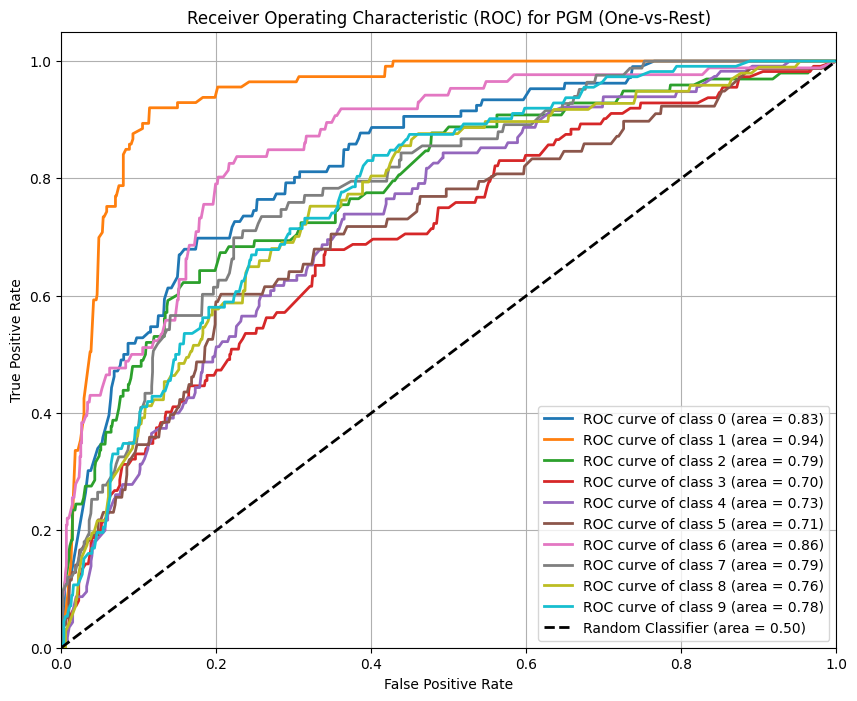

AUC for each class:
Class 0: 0.83
Class 1: 0.94
Class 2: 0.79
Class 3: 0.70
Class 4: 0.73
Class 5: 0.71
Class 6: 0.86
Class 7: 0.79
Class 8: 0.76
Class 9: 0.78


In [73]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Re-generate predictions to get probabilities for each class
pgm_pred_probs = []

print("Generating PGM prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference to get probability distribution over digit_label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    pgm_pred_probs.append(query_result_subset.values.flatten())

pgm_pred_probs = np.array(pgm_pred_probs)

# Binarize the true labels for one-vs-rest ROC
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(pgm_true_labels)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

for i in range(digit_label_cardinality):
    # Ensure we have probabilities for the current class
    if pgm_pred_probs.shape[1] > i:
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for PGM (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("AUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc:
        print(f"Class {i}: {roc_auc[i]:.2f}")

### 12. t-SNE Visualization of PGM Features

Let's apply t-SNE to the raw quadrant features (`raw_features_df`) to visualize how the different digit classes cluster in a 2D space based on these features. This can give us an intuitive understanding of the separability that the PGM is working with.

Shape of data for t-SNE: (1000, 4)
Shape of labels for t-SNE: (1000,)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


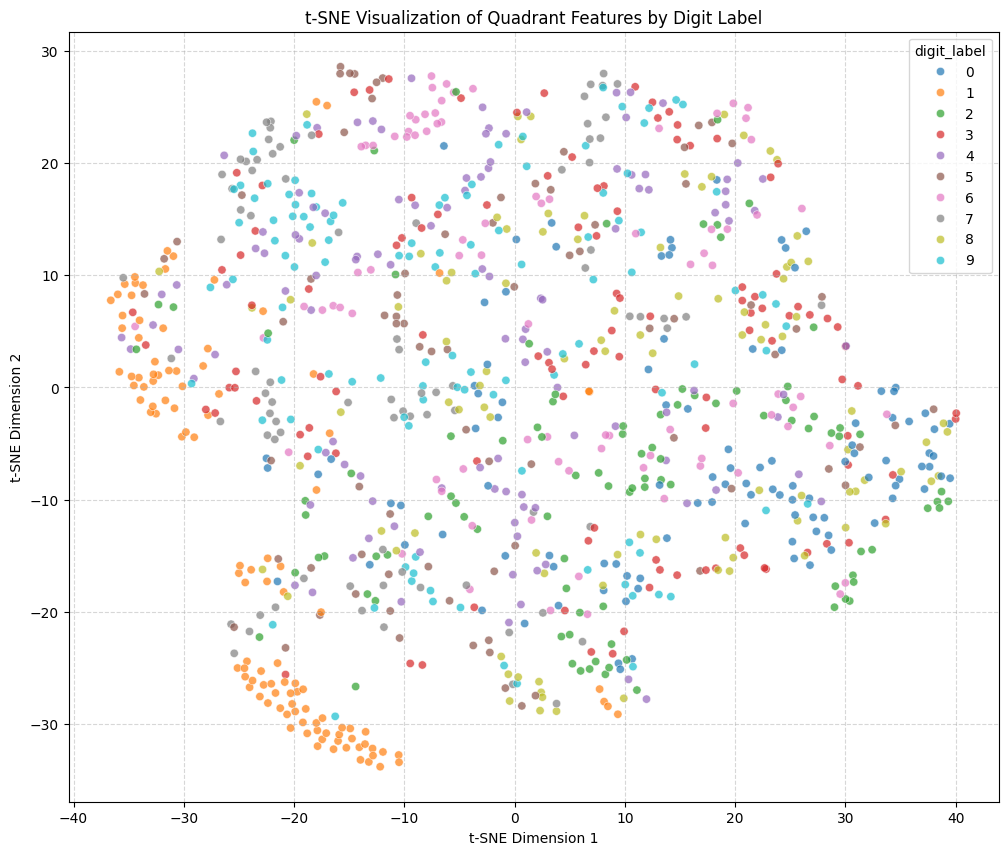

In [74]:
from sklearn.manifold import TSNE

# Prepare data for t-SNE
# We'll use the raw quadrant features and the true digit labels
tsne_data = raw_features_df.values
tsne_labels = y_test_subset

print(f"Shape of data for t-SNE: {tsne_data.shape}")
print(f"Shape of labels for t-SNE: {tsne_labels.shape}")

# Initialize and run t-SNE
# Set a random_state for reproducibility
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(tsne_data)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_results, columns=['tsne_dim_1', 'tsne_dim_2'])
tsne_df['digit_label'] = tsne_labels

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_dim_1',
    y='tsne_dim_2',
    hue='digit_label',
    palette=sns.color_palette('tab10', n_colors=10),
    data=tsne_df,
    legend='full',
    alpha=0.7
)
plt.title('t-SNE Visualization of Quadrant Features by Digit Label')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()